In [1]:
# Importando as bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import statsmodels.api as sm
from statsmodels.api import OLS

In [2]:
# Definindo o caminho correto para o arquivo CSV
file_path = r'C:\Users\lucas\OneDrive\Área de Trabalho\projeto_finance\Finance_data (1).csv'

In [3]:
# Carregar o arquivo CSV
df = pd.read_csv(file_path)

In [4]:
# Exibindo as primeiras linhas para verificar os dados
print(df.head())

   gender  age Investment_Avenues  Mutual_Funds  Equity_Market  Debentures  \
0  Female   34                Yes             1              2           5   
1  Female   23                Yes             4              3           2   
2    Male   30                Yes             3              6           4   
3    Male   22                Yes             2              1           3   
4  Female   24                 No             2              1           3   

   Government_Bonds  Fixed_Deposits  PPF  Gold  ...           Duration  \
0                 3               7    6     4  ...          1-3 years   
1                 1               5    6     7  ...  More than 5 years   
2                 2               5    1     7  ...          3-5 years   
3                 7               6    4     5  ...   Less than 1 year   
4                 6               4    5     7  ...   Less than 1 year   

  Invest_Monitor   Expect       Avenue What are your savings objectives?  \
0        M

In [5]:
import pandas as pd

# Caminho correto para o arquivo CSV
file_path = r'C:\Users\lucas\OneDrive\Área de Trabalho\projeto_finance\Finance_data (1).csv'

# Carregar o arquivo CSV
df = pd.read_csv(file_path)

# Exibindo as primeiras linhas para verificar os dados
df.head()


,gender,age,Investment_Avenues,Mutual_Funds,Equity_Market,Debentures,Government_Bonds,Fixed_Deposits,PPF,Gold,...,Duration,Invest_Monitor,Expect,Avenue,What are your savings objectives?,Reason_Equity,Reason_Mutual,Reason_Bonds,Reason_FD,Source
0,Female,34,Yes,1,2,5,3,7,6,4,...,1-3 years,Monthly,20%-30%,Mutual Fund,Retirement Plan,Capital Appreciation,Better Returns,Safe Investment,Fixed Returns,Newspapers and Magazines
1,Female,23,Yes,4,3,2,1,5,6,7,...,More than 5 years,Weekly,20%-30%,Mutual Fund,Health Care,Dividend,Better Returns,Safe Investment,High Interest Rates,Financial Consultants
2,Male,30,Yes,3,6,4,2,5,1,7,...,3-5 years,Daily,20%-30%,Equity,Retirement Plan,Capital Appreciation,Tax Benefits,Assured Returns,Fixed Returns,Television
3,Male,22,Yes,2,1,3,7,6,4,5,...,Less than 1 year,Daily,10%-20%,Equity,Retirement Plan,Dividend,Fund Diversification,Tax Incentives,High Interest Rates,Internet
4,Female,24,No,2,1,3,6,4,5,7,...,Less than 1 year,Daily,20%-30%,Equity,Retirement Plan,Capital Appreciation,Better Returns,Safe Investment,Risk Free,Internet


In [6]:
# Exibir informações gerais sobre o DataFrame
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 24 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   gender                             40 non-null     object
 1   age                                40 non-null     int64 
 2   Investment_Avenues                 40 non-null     object
 3   Mutual_Funds                       40 non-null     int64 
 4   Equity_Market                      40 non-null     int64 
 5   Debentures                         40 non-null     int64 
 6   Government_Bonds                   40 non-null     int64 
 7   Fixed_Deposits                     40 non-null     int64 
 8   PPF                                40 non-null     int64 
 9   Gold                               40 non-null     int64 
 10  Stock_Marktet                      40 non-null     object
 11  Factor                             40 non-null     object
 12  Objective 

In [7]:
# Estatísticas descritivas básicas
print(df.describe())

             age  Mutual_Funds  Equity_Market  Debentures  Government_Bonds  \
count  40.000000     40.000000      40.000000   40.000000         40.000000   
mean   27.800000      2.550000       3.475000    5.750000          4.650000   
std     3.560467      1.197219       1.131994    1.675617          1.369072   
min    21.000000      1.000000       1.000000    1.000000          1.000000   
25%    25.750000      2.000000       3.000000    5.000000          4.000000   
50%    27.000000      2.000000       4.000000    6.500000          5.000000   
75%    30.000000      3.000000       4.000000    7.000000          5.000000   
max    35.000000      7.000000       6.000000    7.000000          7.000000   

       Fixed_Deposits        PPF       Gold  
count       40.000000  40.000000  40.000000  
mean         3.575000   2.025000   5.975000  
std          1.795828   1.609069   1.143263  
min          1.000000   1.000000   2.000000  
25%          2.750000   1.000000   6.000000  
50%         

In [8]:
# Verificar a presença de valores nulos
print(df.isnull().sum())

gender                               0
age                                  0
Investment_Avenues                   0
Mutual_Funds                         0
Equity_Market                        0
Debentures                           0
Government_Bonds                     0
Fixed_Deposits                       0
PPF                                  0
Gold                                 0
Stock_Marktet                        0
Factor                               0
Objective                            0
Purpose                              0
Duration                             0
Invest_Monitor                       0
Expect                               0
Avenue                               0
What are your savings objectives?    0
Reason_Equity                        0
Reason_Mutual                        0
Reason_Bonds                         0
Reason_FD                            0
Source                               0
dtype: int64


In [9]:

# Verificar valores duplicados
print('Duplicados:', df.duplicated().sum())

Duplicados: 0


In [10]:
# Identificando as colunas numéricas
numerical_columns = df.select_dtypes(include=[np.number]).columns

In [11]:
# Preenchendo valores nulos nas colunas numéricas com a média de cada coluna
df[numerical_columns] = df[numerical_columns].fillna(df[numerical_columns].mean())

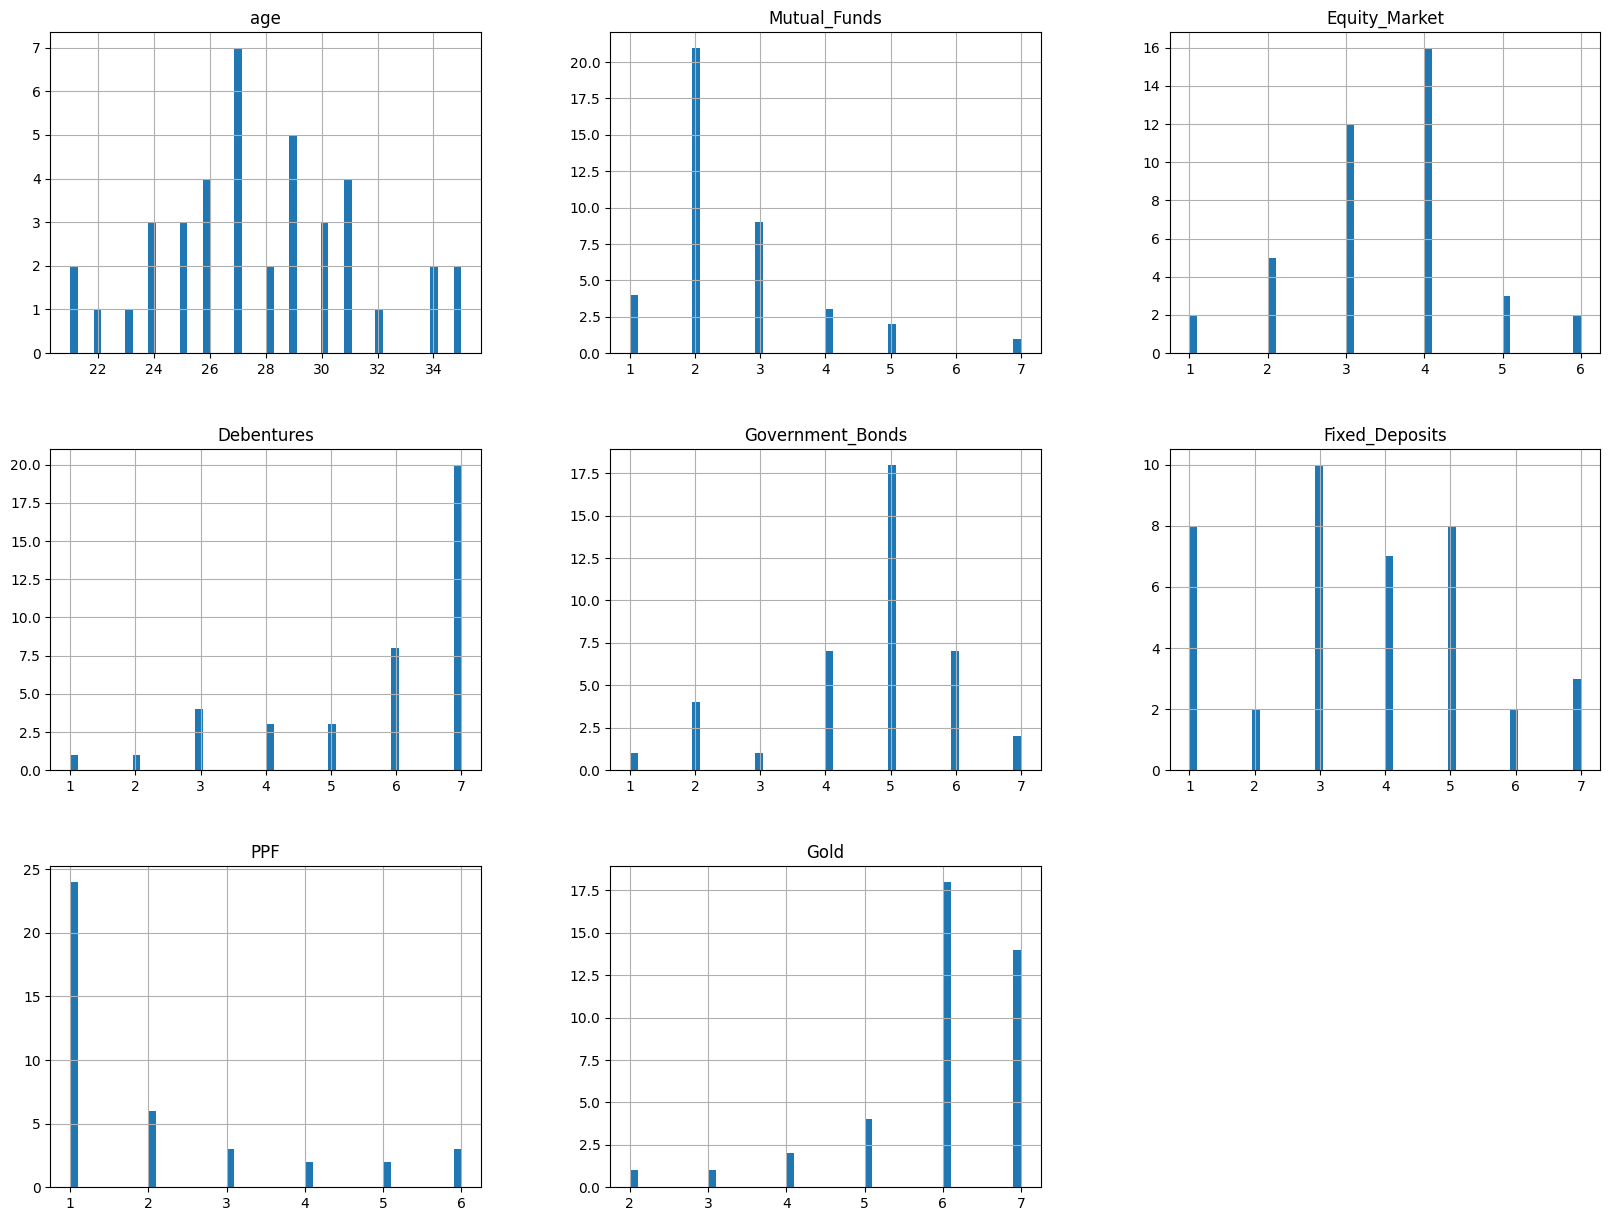

In [12]:
# Visualizando a distribuição dos dados numéricos
df.hist(bins=50, figsize=(20, 15))
plt.show()

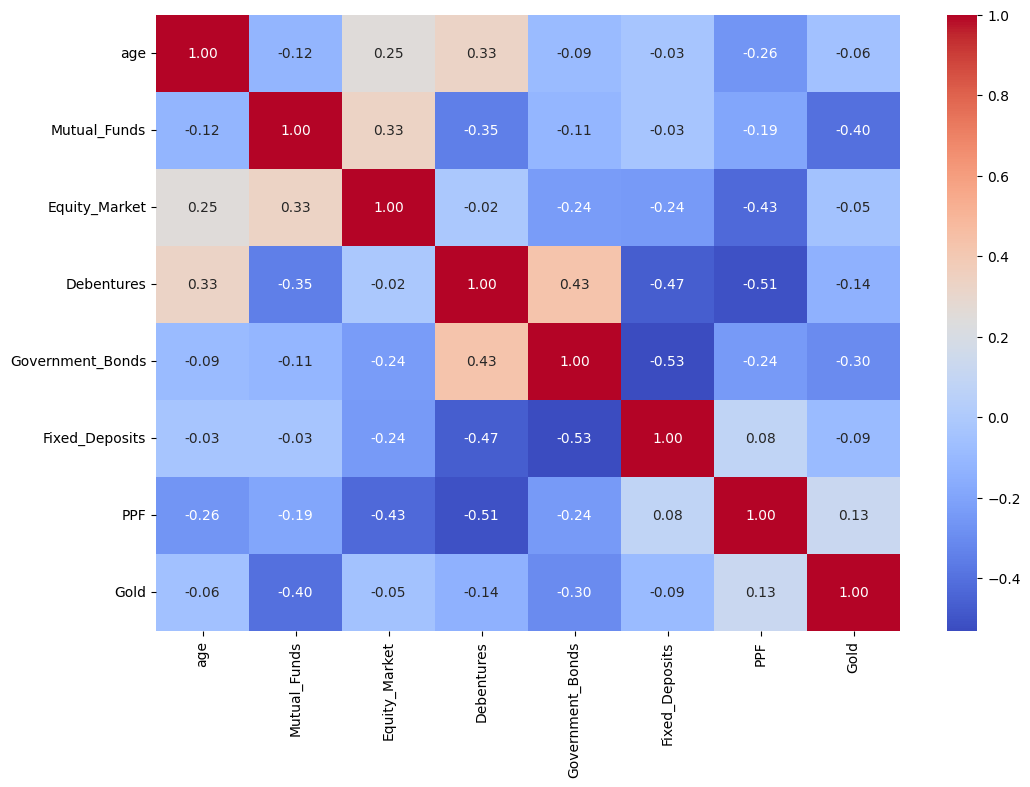

In [14]:
# Análise de correlação entre as variáveis
# Selecionando apenas as colunas numéricas
df_numerical = df.select_dtypes(include=[np.number])

# Análise de correlação entre as variáveis numéricas
plt.figure(figsize=(12, 8))
sns.heatmap(df_numerical.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()



In [17]:
# Adicionando constante para o intercepto
X = sm.add_constant(X)

In [18]:
# Ajustando o modelo de regressão
model = OLS(y, X).fit()

In [19]:
# Exibindo o resumo do modelo
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:           Mutual_Funds   R-squared:                       0.240
Model:                            OLS   Adj. R-squared:                  0.177
Method:                 Least Squares   F-statistic:                     3.789
Date:                Fri, 26 Sep 2025   Prob (F-statistic):             0.0185
Time:                        00:52:24   Log-Likelihood:                -57.963
No. Observations:                  40   AIC:                             123.9
Df Residuals:                      36   BIC:                             130.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             3.5506      1.397      2.542

In [20]:
# Aplicando PCA (Principal Component Analysis) para redução de dimensionalidade
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df.select_dtypes(include=[np.number]))  # Normaliza apenas as variáveis numéricas

In [21]:
pca = PCA(n_components=2)  # Reduzindo para 2 componentes principais
pca_result = pca.fit_transform(df_scaled)

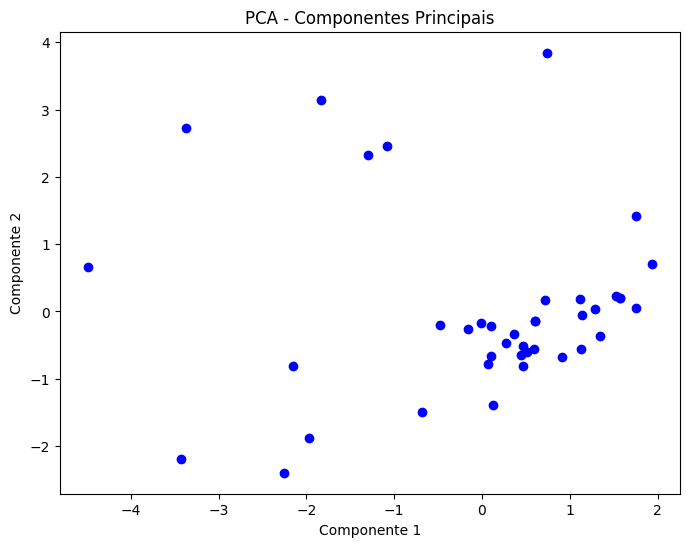

In [22]:
# Visualizando os resultados do PCA
plt.figure(figsize=(8, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], c='blue', marker='o')
plt.title('PCA - Componentes Principais')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.show()


In [23]:
# Seguindo com o modelo de clustering K-Means (se necessário)
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(df_scaled)

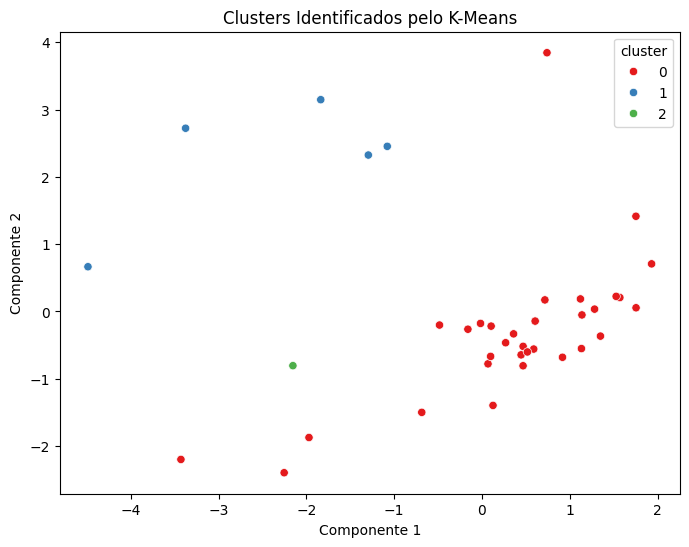

In [24]:
# Visualizando a distribuição dos clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=df['cluster'], palette='Set1')
plt.title('Clusters Identificados pelo K-Means')
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.show()